# Machine Learning
### Bernoulli distribution
The **Bernoulli distribution** is the simplest **discrete** probability distribution, modeling a single random experiment with only two possible outcomes:
- Success (often coded as 1) with probability $p$,
- Failure (coded as 0) with probability $1−p$.

Bernoulli distribution is the building block of the **binomial distribution**.
<hr>

**Probability mass function (PMF):** For a random variable $X\sim Bernoulli(p)$, its PMF is
<br> $\large P(X=x)=p^x \cdot (1-p)^{1-x}$, $x\in\{0,1\}$

Some **properties** of Bernoulli distribution with probability of success $p$:
- Mean: $E[X]=p$
- Variance: $Var[X]=p\cdot (1-p)$
- Entropy: $H(X)=-p\cdot log\,p-(1-p)\cdot log(1-p)$ 
<hr>

**Sampling:** We can generate samples of Bernoulli with success probability $p$ by a continuous uniform random variable. Specifically, if $U\sim Uniform[0, 1]$, then by defining:
<div style="margin:3px">$
X = \begin{cases}
1 & \text{if } U < p \\
0 & \text{otherwise}
\end{cases}
$,
</div>
we get $X\sim Bernoulli (p)$.
<hr>

In the following, we implement a **Python** class for **Bernoulli** distribution, which includes some functions related to the distribution. We also have a function to generate samples of Bernoulli by the help of a continuous **uniform** distribution. At the end, we use some of the functions of the Bernoulli class.
<br> A a **bonus**, we include a simple spam modelling by a Bernoulli distribution.

<hr>

https://github.com/ostad-ai/Machine-Learning
<br> Explanation: https://www.pinterest.com/HamedShahHosseini/Machine-Learning/

In [1]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Bernoulli:
    """
    Bernoulli distribution implementation from scratch.
    """
    
    def __init__(self, p):
        """
        Initialize Bernoulli distribution with 
        success probability p (0<=p<=1).
        """
        if not (0 <= p <= 1):
            raise ValueError("p must be between 0 and 1")
        self.p = p
        self.q = 1 - p  # probability of failure
    
    def pmf(self, x):
        """
        Probability Mass Function.        
        P(X = x) = p^x * (1-p)^(1-x) for x ∈ {0,1}
        """
        x = np.asarray(x)
        if np.any((x != 0) & (x != 1)):
            raise ValueError("x must be 0 or 1")
            
        return np.where(x == 1, self.p, self.q)
    
    def cdf(self, x):
        """
        Compute CDF at x: P(X <= x)
        Works for scalar or array input.
        """
        x = np.asarray(x)
        # Vectorized piecewise definition
        cdf_vals = np.where(
            x < 0, 0.0,
            np.where(x < 1, self.q, 1.0)
        )
        return cdf_vals
    
    def mean(self):
        return self.p
    
    def variance(self):
        return self.p * self.q
    
    def entropy(self):
        """
        Shannon entropy H(X) = -p log p - (1-p) log(1-p)
        Measures uncertainty in nats.
        """
        if self.p == 0 or self.p == 1:
            return 0.0
        
        return -(self.p * np.log(self.p) + self.q * np.log(self.q))
    
    @classmethod
    def fit(cls, data: np.ndarray):
        """
        Estimate p from data using Maximum Likelihood Estimation.
        
        MLE: p̂ = (number of successes) / (total trials)
        """
        data = np.asarray(data)
        
        if not np.all(np.isin(data, [0, 1])):
            raise ValueError("Data must contain only 0s and 1s")
        
        p_hat = np.mean(data)
        return cls(p_hat)
    
    def sample(self, size=1, random_state=None):
        """
        Generate Bernoulli samples using uniform random numbers.
        NO binomial function used.
        """
        if random_state is not None:
            np.random.seed(random_state)
        # Generate uniform random numbers in [0, 1)
        u = np.random.uniform(0, 1, size=size)
        # Threshold at p: 1 if u < p, else 0
        return (u < self.p).astype(int)

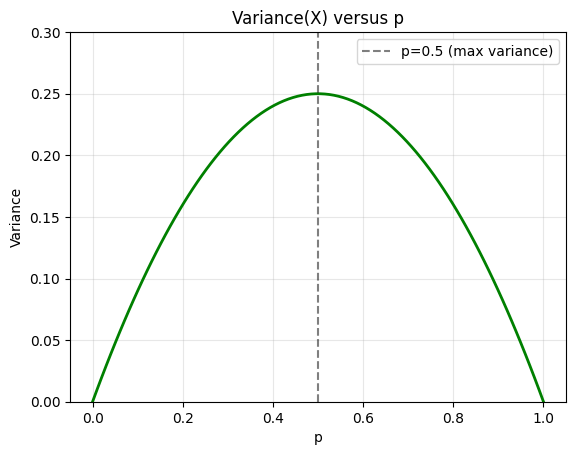

In [3]:
# Variance
p_vals = np.linspace(0, 1, 100)
variances = [Bernoulli(p).variance() for p in p_vals]
plt.plot(p_vals, variances, 'g-', linewidth=2)
plt.axvline(x=0.5, color='k', linestyle='--', 
            alpha=0.5, label='p=0.5 (max variance)')
plt.xlabel('p')
plt.ylabel('Variance')
plt.title('Variance(X) versus p')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, .3)
plt.show()

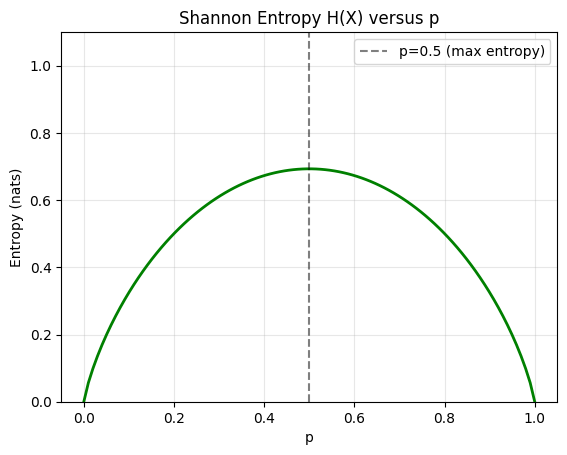

In [4]:
# Entropy
p_vals = np.linspace(0, 1, 100)
entropies = [Bernoulli(p).entropy() for p in p_vals]
plt.plot(p_vals, entropies, 'g-', linewidth=2)
plt.axvline(x=0.5, color='k', linestyle='--', 
            alpha=0.5, label='p=0.5 (max entropy)')
plt.xlabel('p')
plt.ylabel('Entropy (nats)')
plt.title('Shannon Entropy H(X) versus p')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.show()

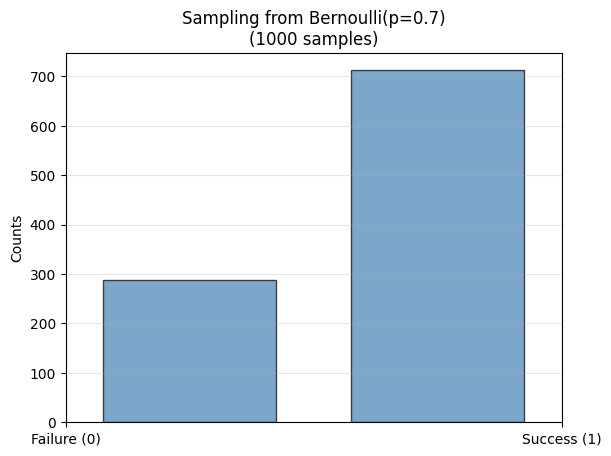

In [5]:
# Sampling demonstration
p=0.7
dist = Bernoulli(p)
samples = dist.sample(size=1000, random_state=42)
plt.hist(samples, bins=2, rwidth=.7, alpha=0.7, color='steelblue', 
        edgecolor='black', density=False)
plt.xticks([0,1],['Failure (0)', 'Success (1)'])
plt.ylabel('Counts')
plt.title(f'Sampling from Bernoulli(p={dist.p:.1f})\n(1000 samples)')
plt.grid(True, alpha=0.3)
plt.show()

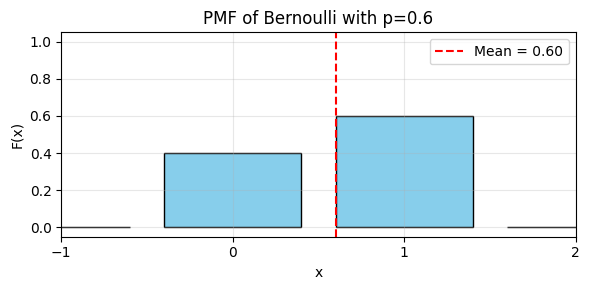

In [6]:
# Plot pmf
p=.6
dist_pmf=Bernoulli(p)
# Extend range slightly for visualization
x_pmf=[0,1]
x_min = - 1
x_max = 2
x_plot = list(range(x_min, x_max+1))
y_plot=[]
for x in x_plot:
    if x in x_pmf:
        y_plot.append(dist_pmf.pmf(x))
    else:
        y_plot.append(0)
plt.figure(figsize=(6, 3))
plt.bar(x_plot, y_plot, width=0.8, color='skyblue', edgecolor='black')
plt.axvline(dist_pmf.mean(), color='r', linestyle='--', 
            label=f'Mean = {dist_pmf.mean():.2f}')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title(f'PMF of Bernoulli with p={p}')
plt.ylim(-0.05, 1.05)
plt.xlim(x_min, x_max)
plt.xticks(np.arange(x_min, x_max + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

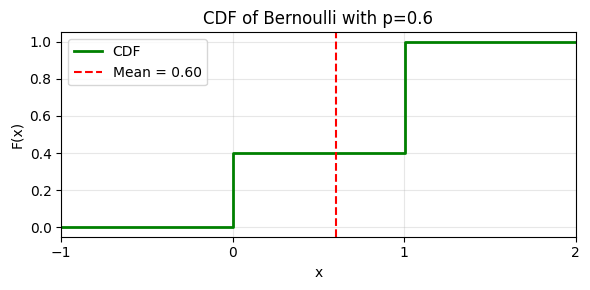

In [7]:
# Plot cdf
p=.6
dist2=Bernoulli(p)
# Extend range slightly for visualization
x_min = - 1
x_max = 2
x_plot = np.linspace(x_min, x_max, 500)
y_plot = dist2.cdf(x_plot)
plt.figure(figsize=(6, 3))
plt.plot(x_plot, y_plot, 'g-', drawstyle='steps-post', lw=2, label='CDF')
plt.axvline(dist2.mean(), color='r', linestyle='--', label=f'Mean = {dist2.mean():.2f}')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title(f'CDF of Bernoulli with p={p}')
plt.ylim(-0.05, 1.05)
plt.xlim(x_min, x_max)
plt.xticks(np.arange(x_min, x_max + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<hr style="height:3px;background:lightgreen">

# Bonus
#### Email spams modellng by Bernoulli distribution


In [8]:
"""Email spam modelling"""
# Assume that
p_spam = 0.6  # 60% of emails are spam
daily_emails = 1000000  # 1 million emails

# models by Bernoulli
dist_spam=Bernoulli(p_spam)
spam_emails = dist_spam.sample(daily_emails)
n_spam = np.sum(spam_emails)

print(f"Daily email volume: {daily_emails:,}")
print(f"  Spam emails: {n_spam:,} ({n_spam/daily_emails:.1%})")
print(f"  Legitimate emails: {daily_emails - n_spam:,}")

# Storage savings
# assume that each spam takes 0.05 MB space
avg_spam_size_mb = 0.05
storage_saved = n_spam * avg_spam_size_mb / 1000  # GB
print(f"  Storage saved by filtering: {storage_saved:.1f} GB/day")

Daily email volume: 1,000,000
  Spam emails: 599,433 (59.9%)
  Legitimate emails: 400,567
  Storage saved by filtering: 30.0 GB/day
